# I. Import các thư viện

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
import matplotlib.ticker as ticker
import statsmodels.api as sm

%matplotlib inline

# II. Import Data

In [3]:
df = pd.read_csv('E:\Document\PROJECT_1\data\data (2023-2024).csv')
df.head()

,UTC Time,Local Time,City,Country Code,Timezone,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed
0,2022-12-31T17:00:00,1/1/2023 0:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,155,224.5,9.0,55.7,73.8,59.0,62.3,87,0.0,1024,73,14.8,0.0,0.66
1,2022-12-31T18:00:00,1/1/2023 1:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,171,206.0,6.0,56.0,88.8,71.0,59.0,87,0.0,1023,75,14.6,0.0,1.00
2,2022-12-31T19:00:00,1/1/2023 2:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,179,203.7,6.0,54.0,96.3,77.0,58.0,83,0.0,1023,79,14.3,0.0,1.00
3,2022-12-31T20:00:00,1/1/2023 3:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,199,201.3,6.0,52.0,115.0,92.0,57.0,79,0.0,1023,82,14.1,0.0,1.00
4,2022-12-31T21:00:00,1/1/2023 4:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,161,199.0,6.0,50.0,80.0,64.0,56.0,75,0.0,1022,86,13.8,0.0,1.00


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17544 entries, 0 to 17543
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   UTC Time           17544 non-null  object 
 1   Local Time         17544 non-null  object 
 2   City               17544 non-null  object 
 3   Country Code       17544 non-null  object 
 4   Timezone           17544 non-null  object 
 5   AQI                17544 non-null  int64  
 6   CO                 17544 non-null  float64
 7   NO2                17544 non-null  float64
 8   O3                 17544 non-null  float64
 9   PM10               17544 non-null  float64
 10  PM25               17544 non-null  float64
 11  SO2                17544 non-null  float64
 12  Clouds             17544 non-null  int64  
 13  Precipitation      17544 non-null  float64
 14  Pressure           17544 non-null  int64  
 15  Relative Humidity  17544 non-null  int64  
 16  Temperature        175

In [5]:
df.shape

(17544, 19)

## 2.1 Mô tả dữ liệu

Tập dữ liệu bao gồm **dữ liệu chất lượng không khí theo giờ** trong khoảng thời gian **từ 00:00:00 ngày 01/01/2023 đến 00:00:00 ngày 01/01/2025**,  
với **17.544 hàng** và **19 cột**.  
Không có giá trị bị thiếu (`NaN`) trong toàn bộ khung dữ liệu.

---

####  Thời gian, địa điểm
- **UTC Time** – Thời gian quốc tế (Coordinated Universal Time)  
- **Local Time** – Thời gian địa phương (Việt Nam)  
- **City** – Thành phố đo đạc  
- **Timezone** – Múi giờ

---

#### Chất lượng không khí
- **AQI** – Chỉ số chất lượng không khí tổng hợp  
- **CO** – Carbon Monoxide *(mg/m³)*  
- **NO2** – Nitrogen Dioxide *(µg/m³)*  
- **O3** – Ozone *(µg/m³)*  
- **PM10** – Bụi mịn có đường kính ≤ 10 µm *(µg/m³)*  
- **PM25** – Bụi mịn có đường kính ≤ 2.5 µm *(µg/m³)*  
- **SO2** – Sulfur Dioxide *(µg/m³)*  

---

####  Các yếu tố khí tượng
- **Clouds** – Mức độ mây bao phủ (%)  
- **Precipitation** – Lượng mưa *(mm)*  
- **Pressure** – Áp suất khí quyển *(hPa)*  
- **Relative Humidity** – Độ ẩm tương đối (%)  
- **Temperature** – Nhiệt độ *(°C)*  
- **UV Index** – Chỉ số tia cực tím  
- **Wind Speed** – Tốc độ gió *(m/s)*  

---




# III. Phân tích và khám phá dữ liệu
Trong phần này, phân tích khám phá dữ liệu (EDA) sẽ được sử dụng để xem xét bộ dữ liệu nhằm tìm kiếm các khuôn mẫu, phát hiện bất thường, kiểm định giả thuyết và xác minh các giả định. Quá trình này được thực hiện thông qua các thống kê mô tả và biểu đồ trực quan.

Trong suốt hơn 45 năm qua, Chỉ số Chất lượng Không khí (Air Quality Index – AQI), được phát triển bởi Cơ quan Bảo vệ Môi trường Hoa Kỳ (USEPA), đã cung cấp những thông tin quan trọng cho công chúng về tình trạng ô nhiễm không khí.
Chỉ số AQI được tính toán dựa trên nồng độ đo được của các chất ô nhiễm bao gồm: Carbon Monoxide (CO), Nitrogen Dioxide (NO2), Ozone (O3), hạt bụi mịn PM2.5 và PM10, cùng với Sulfur Dioxide (SO2).

Trong đó, PM25 (biểu thị vật có đường kính nhỏ hơn hoặc bằng 2.5 micromet) là yếu tố chính gây nguy hại đến sức khỏe con người, và thường được sử dụng như chỉ tiêu quan trọng trong các tiêu chuẩn đánh giá chất lượng không khí.

Theo Báo cáo Chất lượng Không khí Toàn cầu năm 2019 của [IQAir](https://www.iqair.com/vi/newsroom/resources-what-is-aqi), nồng độ PM₂.₅ được chia thành các nhóm mức độ khác nhau để xác định tình trạng chất lượng không khí, cụ thể như sau:

![anh.png](./images/anh.png)

## 3.1 Mô tả dữ liệu

In [6]:
df.describe()

,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed
count,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000
mean,119.188440,586.002194,26.046255,53.999806,69.853836,49.333772,66.193382,70.481190,0.287819,1009.855734,77.972811,25.367522,1.334131,1.616586
std,54.214466,969.613080,28.068960,44.883112,84.185750,42.314439,49.174271,31.187022,1.031729,7.434626,15.235786,5.479729,1.952395,0.820656
min,4.000000,0.000000,2.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,983.000000,17.000000,7.700000,0.000000,0.000000
25%,76.000000,135.400000,11.300000,22.300000,31.800000,24.000000,26.000000,50.000000,0.000000,1004.000000,68.000000,21.600000,0.000000,1.000000
50%,108.000000,212.400000,18.000000,41.700000,50.000000,38.000000,61.300000,79.000000,0.000000,1009.000000,82.000000,26.200000,0.600000,1.600000
75%,154.000000,571.300000,29.000000,74.000000,80.000000,59.000000,97.000000,100.000000,0.000000,1015.000000,91.000000,29.200000,2.100000,2.000000
max,500.000000,15956.200000,378.000000,700.000000,1103.000000,446.000000,400.000000,100.000000,21.750000,1033.000000,100.000000,40.000000,12.100000,12.400000


In [7]:
df.head(5)

,UTC Time,Local Time,City,Country Code,Timezone,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed
0,2022-12-31T17:00:00,1/1/2023 0:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,155,224.5,9.0,55.7,73.8,59.0,62.3,87,0.0,1024,73,14.8,0.0,0.66
1,2022-12-31T18:00:00,1/1/2023 1:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,171,206.0,6.0,56.0,88.8,71.0,59.0,87,0.0,1023,75,14.6,0.0,1.00
2,2022-12-31T19:00:00,1/1/2023 2:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,179,203.7,6.0,54.0,96.3,77.0,58.0,83,0.0,1023,79,14.3,0.0,1.00
3,2022-12-31T20:00:00,1/1/2023 3:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,199,201.3,6.0,52.0,115.0,92.0,57.0,79,0.0,1023,82,14.1,0.0,1.00
4,2022-12-31T21:00:00,1/1/2023 4:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,161,199.0,6.0,50.0,80.0,64.0,56.0,75,0.0,1022,86,13.8,0.0,1.00


## 3.2 AQI (Chỉ số chất lượng không khí)
### 3.2.1 AQI theo giờ của Hà Nội năm 2023, 2024

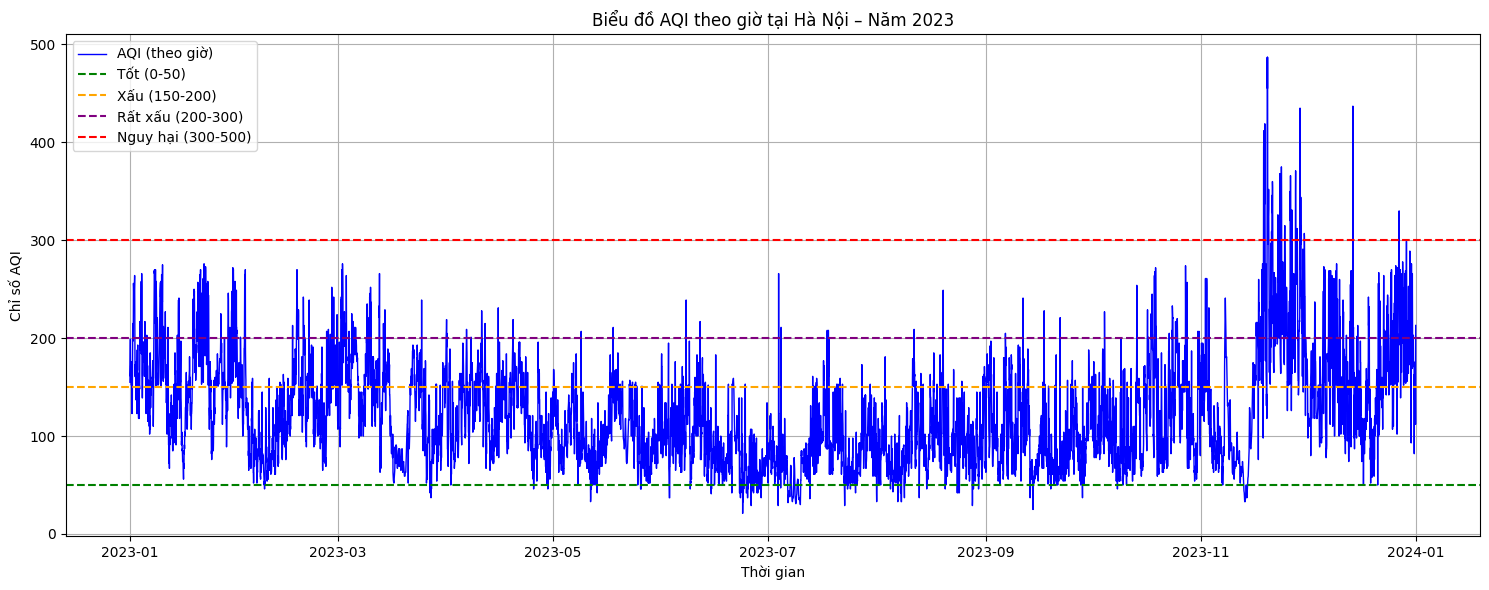

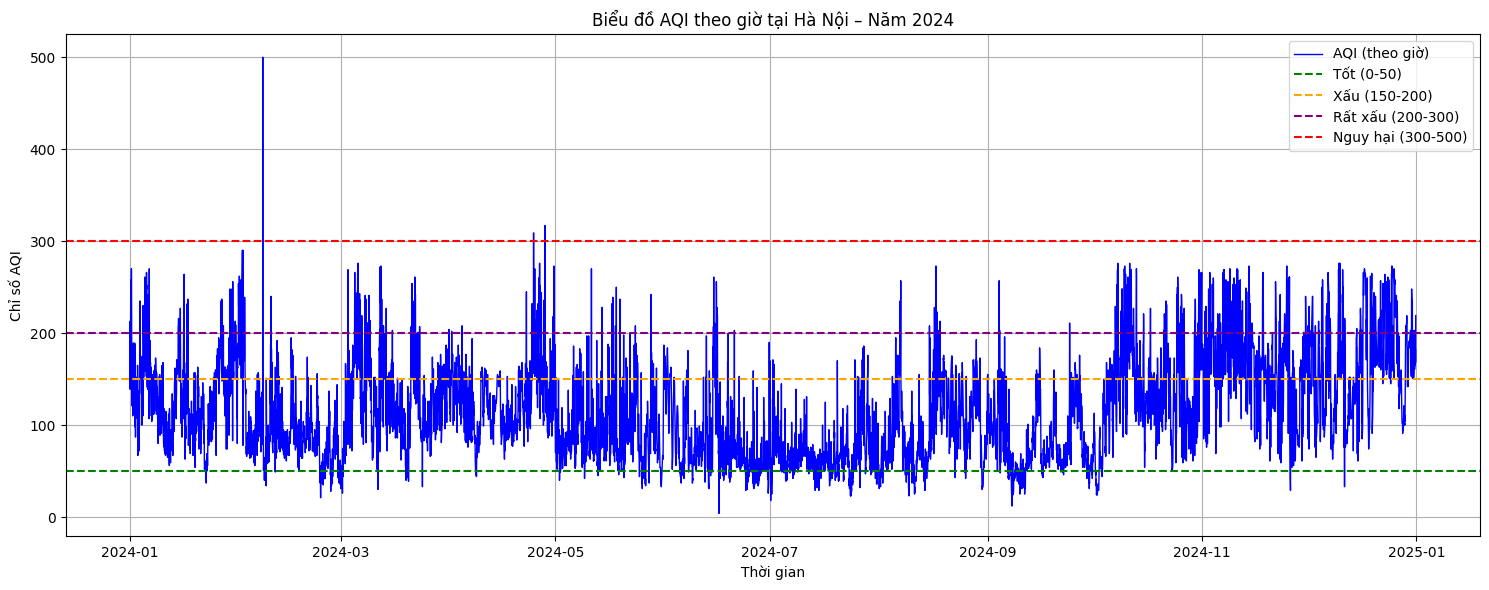

Năm 2023: AQI cao nhất = 487 vào lúc 2023-11-19 20:00:00
Năm 2024: AQI cao nhất = 500 vào lúc 2024-02-07 19:00:00


In [8]:
df['Local Time'] = pd.to_datetime(df['Local Time'])

df_2023 = df[df['Local Time'].dt.year == 2023]
df_2024 = df[df['Local Time'].dt.year == 2024]

# Biểu đồ năm 2023
plt.figure(figsize=(15,6))
plt.plot(df_2023['Local Time'], df_2023['AQI'], color='blue', linewidth=1, label='AQI (theo giờ)')
plt.title('Biểu đồ AQI theo giờ tại Hà Nội – Năm 2023')
plt.xlabel('Thời gian')
plt.ylabel('Chỉ số AQI')
plt.axhline(y=50, color='green', linestyle='--', label='Tốt (0-50)')
plt.axhline(y=150, color='orange', linestyle='--', label='Xấu (150-200)')
plt.axhline(y=200, color='purple', linestyle='--', label='Rất xấu (200-300)')
plt.axhline(y=300, color='red', linestyle='--', label='Nguy hại (300-500)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Biểu đồ năm 2024
plt.figure(figsize=(15,6))
plt.plot(df_2024['Local Time'], df_2024['AQI'], color='blue', linewidth=1, label='AQI (theo giờ)')
plt.title('Biểu đồ AQI theo giờ tại Hà Nội – Năm 2024')
plt.xlabel('Thời gian')
plt.ylabel('Chỉ số AQI')
plt.axhline(y=50, color='green', linestyle='--', label='Tốt (0-50)')
plt.axhline(y=150, color='orange', linestyle='--', label='Xấu (150-200)')
plt.axhline(y=200, color='purple', linestyle='--', label='Rất xấu (200-300)')
plt.axhline(y=300, color='red', linestyle='--', label='Nguy hại (300-500)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


max_2023 = df_2023.loc[df_2023['AQI'].idxmax()]
max_2024 = df_2024.loc[df_2024['AQI'].idxmax()]
print(f"Năm 2023: AQI cao nhất = {max_2023['AQI']} vào lúc {max_2023['Local Time']}")
print(f"Năm 2024: AQI cao nhất = {max_2024['AQI']} vào lúc {max_2024['Local Time']}")


**-> KẾT LUẬN:** Từ biểu đồ, có thể thấy chỉ số AQI của Hà Nội dao động chủ yếu trong khoảng 50-200 (Trung bình đến Xấu). Chỉ số này ít khi duy trì ở mức "Tốt" (0-50). Chỉ số cũng có tần suất cao vượt ngưỡng "Không tốt". Đặc biệt, chỉ số này ở mức "Nguy hại" (>300) vào các thời điểm khác nhau từ tháng 11 đến giữa tháng 2, đạt mức cao nhất trong năm vào lúc 19h 7/2/2024 và đạt AQI = 487 vào lúc 20h ngày 19/11/2023.

Nhìn chung, Hà Nội đã phải đối mặt với tình trạng ô nhiễm không khí nghiêm trọng trong năm qua, điều này có thể ảnh hưởng nghiêm trọng đến sức khỏe của người dân thành phố.



### 3.2.2 Các tháng có AQI ở mức "Nguy hại"

In [9]:

df['month'] = df['Local Time'].dt.month
df['year'] = df['Local Time'].dt.year

monthly_stats = (df.groupby(['year', 'month']).agg(
    mean_AQI = ('AQI', 'mean'),
    max_AQI = ('AQI', 'max'),
    std_AQI = ('AQI', 'std'),
    count_hazardous=('AQI', lambda x: (x>300).sum())
    
).reset_index()
                )
monthly_stats = monthly_stats.sort_values('mean_AQI', ascending=False)
months_over_300 = monthly_stats[monthly_stats['count_hazardous'] > 0]
print(months_over_300[['year', 'month', 'mean_AQI', 'count_hazardous']])


    year  month    mean_AQI  count_hazardous
10  2023     11  166.684722               52
11  2023     12  165.413978                2
15  2024      4  128.120666                2
13  2024      2   96.771552                1


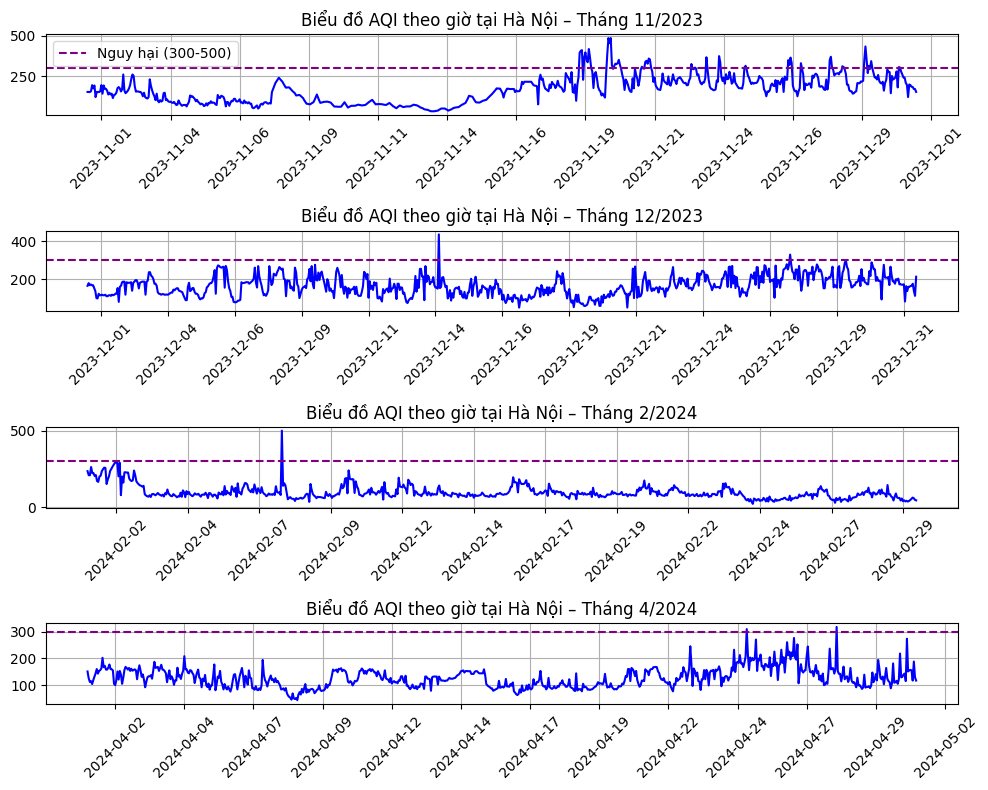

In [10]:
df.set_index('Local Time', inplace=True)
fig, axs = plt.subplots(4, 1, figsize=(10, 8))

# Vẽ biểu đồ cho từng tháng
axs[0].plot(df.loc['2023-11-01':'2023-11-30']["AQI"], color='b')
axs[0].set_title('Biểu đồ AQI theo giờ tại Hà Nội – Tháng 11/2023')
axs[0].grid(True)
axs[0].axhline(y=300, color='purple', linestyle='--', label='Nguy hại (300-500)')
axs[0].legend()


axs[1].plot(df.loc['2023-12-01':'2023-12-31']["AQI"], color='b')
axs[1].set_title('Biểu đồ AQI theo giờ tại Hà Nội – Tháng 12/2023')
axs[1].grid(True)
axs[1].axhline(y=300, color='purple', linestyle='--', label='Nguy hại (300-500)')


axs[2].plot(df.loc['2024-02-01':'2024-02-29']["AQI"], color='b')
axs[2].set_title('Biểu đồ AQI theo giờ tại Hà Nội – Tháng 2/2024')
axs[2].grid(True)
axs[2].axhline(y=300, color='purple', linestyle='--', label='Nguy hại (300-500)')


axs[3].plot(df.loc['2024-04-01':'2024-04-30']["AQI"], color='b')
axs[3].set_title('Biểu đồ AQI theo giờ tại Hà Nội – Tháng 4/2024')
axs[3].grid(True)
axs[3].axhline(y=300, color='purple', linestyle='--', label='Nguy hại (300-500)')


for ax in axs:
    ax.xaxis.set_major_locator(plt.MaxNLocator(15))
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Các tháng có mức AQI nguy hiểm là tháng 11, 12, 2, 4. Khi xem xét ba biểu đồ được cung cấp, có thể thấy rõ rằng tháng 11 chứng kiến ​​sự xuất hiện thường xuyên của các mức AQI nguy hiểm, đặc biệt là trong nửa cuối tháng. Ngược lại, tháng 12, 2, 4 chỉ có một ngày AQI đạt đến mức nguy hiểm.

Nguyên nhân xảy ra sự cố tháng 11 đã được VnExpress giải thích trong bài [“Chất lượng không khí Hà Nội giảm xuống mức nguy hại”](https://vnexpress.net/chat-luong-khong-khi-ha-noi-dang-rat-xau-4834405.html). Theo bài báo, Cục Kiểm soát ô nhiễm Việt Nam lưu ý rằng điều kiện thời tiết khô hạn ở Hà Nội khiến bụi phát tán trên diện rộng. Ngoài ra, việc đốt rác và nông sản còn sót lại được xác định là góp phần làm tăng mức độ ô nhiễm.

### 3.2.3 AQI ở các kỳ nghỉ lễ

AQI trung bình (Ngày thường vs Ngày Lễ):
 Ngày thường: 118.7
 Ngày lễ:     131.6


C:\Users\hungd\AppData\Local\Temp\ipykernel_18928\1377036330.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsHoliday', y='AQI', data=df, palette='pastel')


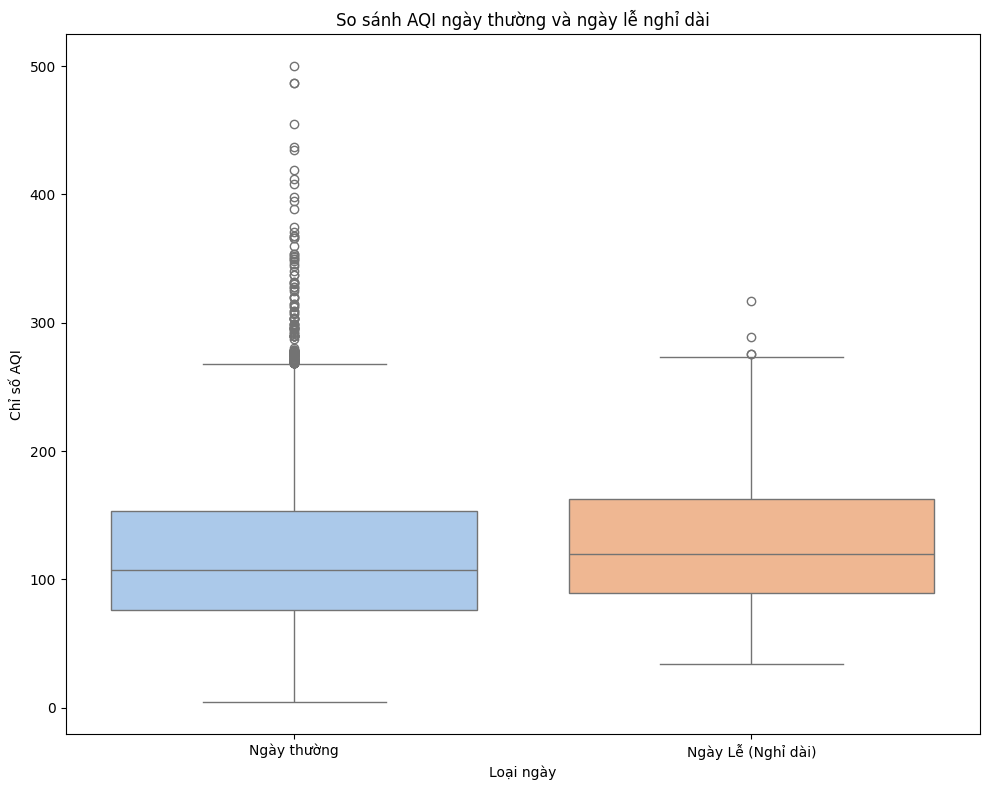

In [11]:
holiday_periods = {
        'Tết 2023': ('2023-01-20', '2023-01-26'),
        'Lễ 30/4-1/5 2023': ('2023-04-29', '2023-05-03'),
        'Lễ 2/9 2023': ('2023-09-01', '2023-09-04'),
        'Tết Dương 2024': ('2023-12-30', '2024-01-01'),
        'Tết 2024': ('2024-02-08', '2024-02-14'),
        'Lễ 30/4-1/5 2024': ('2024-04-27', '2024-05-01'),
        'Lễ 2/9 2024': ('2024-08-31', '2024-09-03')
    }

df['HolidayName'] = 'Ngày thường'
for name, (start, end) in holiday_periods.items():     
    df.loc[df.index.isin(pd.date_range(start, end, freq='h')), 'HolidayName'] = name
    
df['IsHoliday'] = df['HolidayName'] != 'Ngày thường'
holiday_aqi_stats = df.groupby('IsHoliday')['AQI'].mean()
normal_aqi = holiday_aqi_stats.loc[False]
holiday_aqi = holiday_aqi_stats.loc[True]

print("AQI trung bình (Ngày thường vs Ngày Lễ):")
print(f" Ngày thường: {normal_aqi:.1f}")
print(f" Ngày lễ:     {holiday_aqi:.1f}")

plt.figure(figsize=(10, 8))
sns.boxplot(x='IsHoliday', y='AQI', data=df, palette='pastel')
plt.xticks([False, True], ['Ngày thường', 'Ngày Lễ (Nghỉ dài)'])
plt.title('So sánh AQI ngày thường và ngày lễ nghỉ dài')
plt.xlabel('Loại ngày')
plt.ylabel('Chỉ số AQI')
plt.tight_layout()
plt.show() 

**-> NHẬN XÉT:**

Biểu đồ so sánh tổng quan cho thấy một kết quả khá bất ngờ:
* AQI trung bình (Ngày thường): **118.7**
* AQI trung bình (Ngày Lễ): **131.6**

Trái với giả thuyết rằng các kỳ nghỉ dài (người dân về quê, giao thông giảm) sẽ làm không khí sạch hơn, dữ liệu lại cho thấy điều ngược lại.

Biểu đồ phân phối chi tiết theo từng kỳ nghỉ lễ lý giải điều này: **Yếu tố "Mùa" quan trọng hơn yếu tố "Lễ".**

1.  **Các kỳ nghỉ Mùa Đông/Xuân (Ô nhiễm):** Các đợt nghỉ dài nhất (`Tết 2023`, `Tết Dương 2024`, `Tết 2024`) đều rơi vào đúng "mùa ô nhiễm" (tháng 12, 1, 2). Mặc dù giao thông giảm, các yếu tố thời tiết (lặng gió, nghịch nhiệt) và hoạt động lễ hội (đốt vàng mã) giữ cho mức AQI ở ngưỡng rất cao.
2.  **Các kỳ nghỉ Mùa Hè/Thu (Không khí sạch):** Các kỳ nghỉ (`Lễ 30/4-1/5`, `Lễ 2/9`) đều rơi vào "mùa sạch" trong năm, do đó có mức AQI trung bình thấp và ổn định.

**Kết luận:** Ảnh hưởng của các kỳ nghỉ lễ đến AQI bị lấn át hoàn toàn bởi tính mùa vụ của thời tiết.

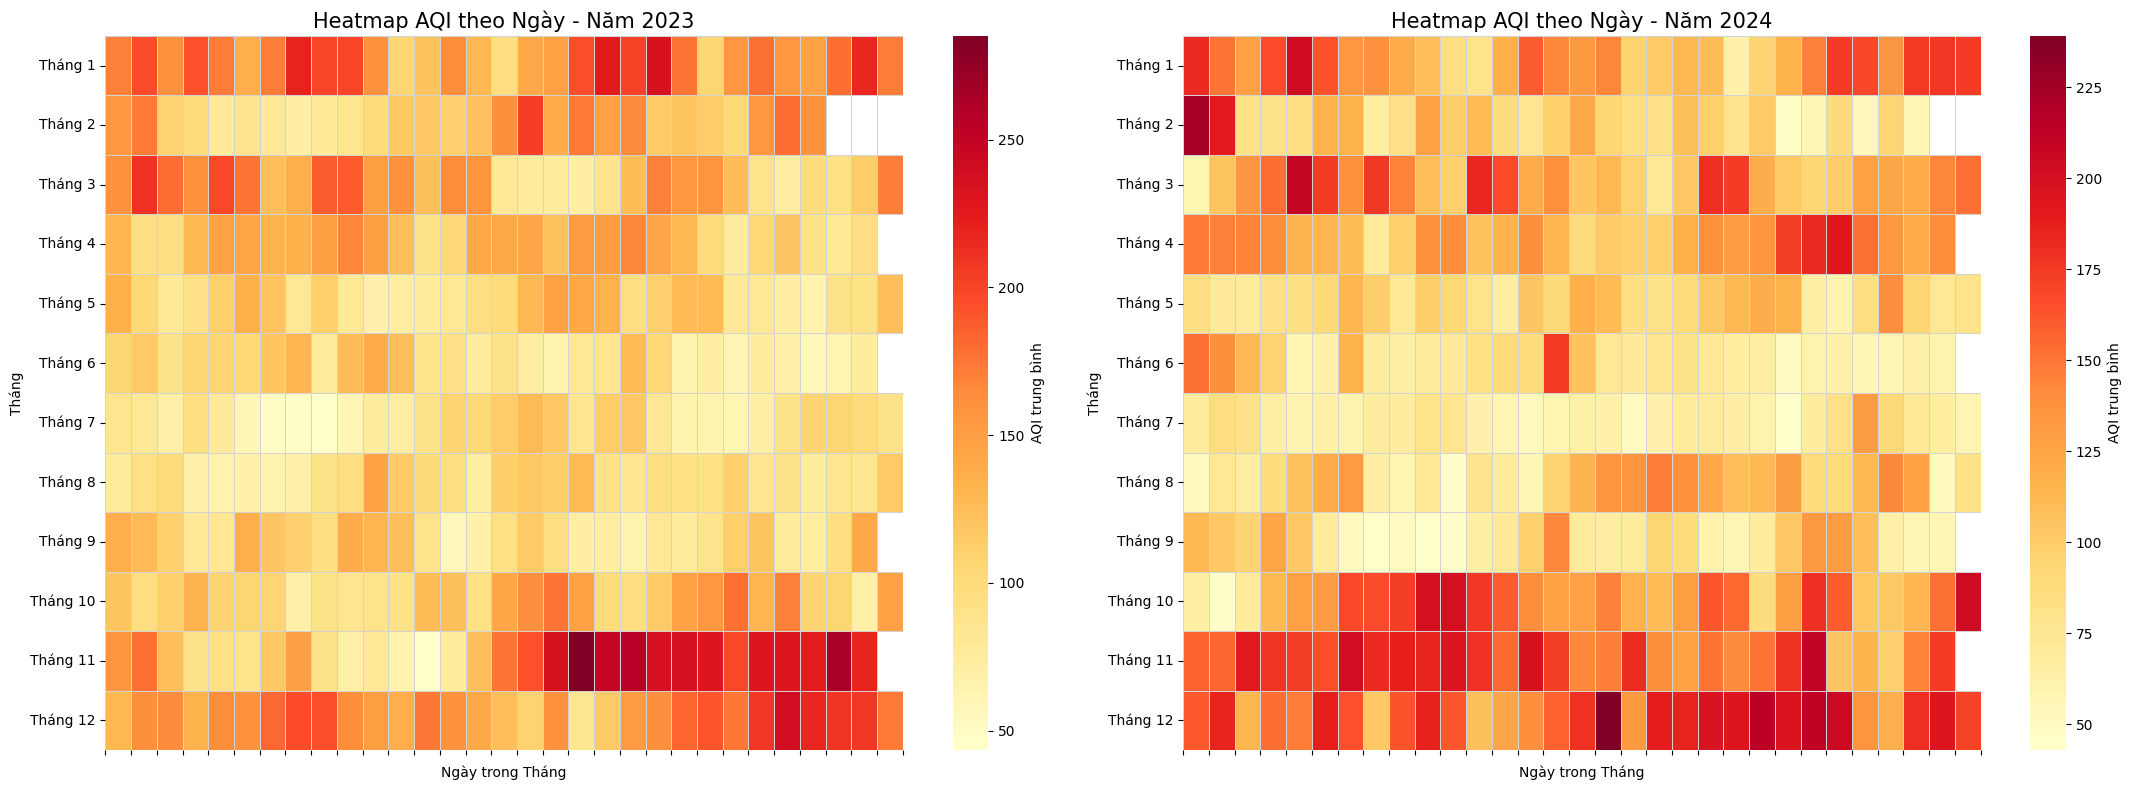

In [12]:

daily_aqi = df['AQI'].resample('D').mean()

def make_heatmap(series, year, ax):
    year_data = series.loc[str(year)]

    data = year_data.to_frame('AQI')
    data['Month'] = data.index.month
    data['Day'] = data.index.day

    heatmap_data = (
        data.pivot_table(index='Month', columns='Day', values='AQI', aggfunc='mean')
            .reindex(index=range(1, 13), columns=range(1, 32))
    )

    sns.heatmap(
        heatmap_data,
        ax=ax,
        cmap='YlOrRd',
        linewidths=0.5,
        linecolor='lightgrey',
        cbar_kws={'label': 'AQI trung bình'}
    )

    month_names = ['Tháng 1','Tháng 2','Tháng 3','Tháng 4','Tháng 5','Tháng 6',
                   'Tháng 7','Tháng 8','Tháng 9','Tháng 10','Tháng 11','Tháng 12']
    ax.set_yticklabels([month_names[i-1] for i in heatmap_data.index], rotation=0)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.set_xlabel('Ngày trong Tháng')
    ax.set_ylabel('Tháng')
    ax.set_title(f'Heatmap AQI theo Ngày - Năm {year}', fontsize=15)


fig, axes = plt.subplots(1, 2, figsize=(22, 8))

make_heatmap(daily_aqi, 2023, axes[0])
make_heatmap(daily_aqi, 2024, axes[1])

plt.tight_layout()
plt.show()


## 3.3 Nồng độ bụi mịn PM2.5
Theo [VnExpress](https://e.vnexpress.net/news/environment/hanoi-s-air-quality-dropping-over-large-scales-4719205.html), nghiên cứu của Bộ Tài nguyên và Môi trường Việt Nam chỉ ra rằng ô nhiễm không khí ở Hà Nội chủ yếu đến từ bụi PM2.5 ảnh hưởng nặng nề đến sức khỏe người dân. Vì vậy, chúng ta sẽ có cái nhìn sâu hơn về chỉ số PM2.5 của Hà Nội trong năm 2023, 2024.
### 3.3.1 Biểu đồ tỉ lệ PM2.5 theo giờ trong năm 2023 và 2024

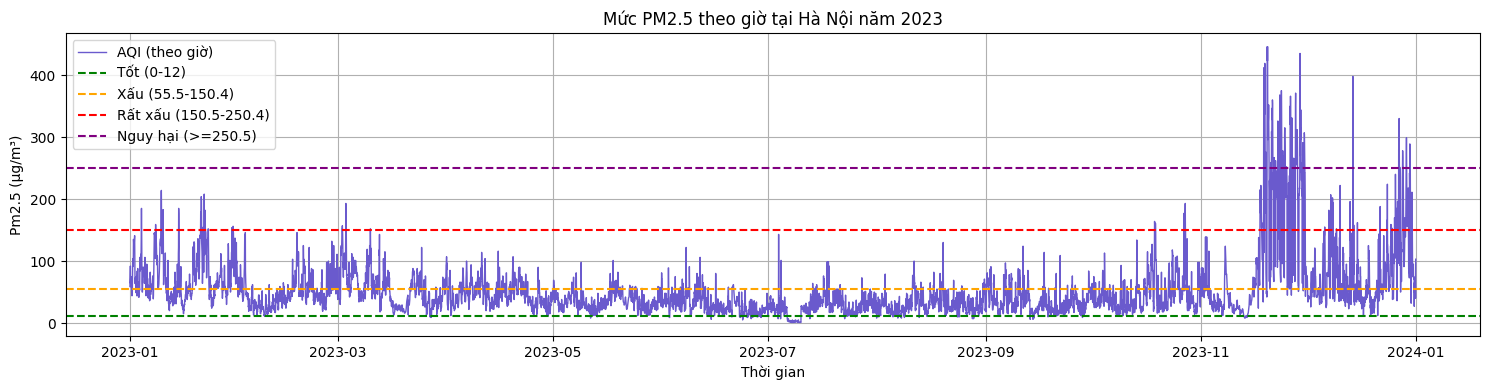

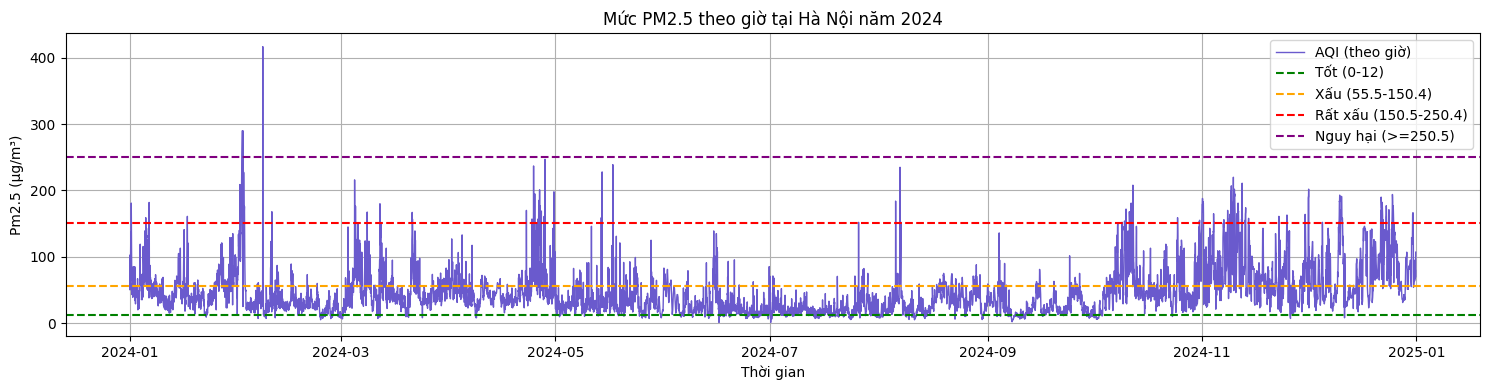

In [13]:
# Năm 2023

plt.figure(figsize=(15, 4))
plt.plot(df_2023['Local Time'], df_2023['PM25'], color='slateblue', linewidth=1, label='AQI (theo giờ)')
plt.xlabel('Thời gian')
plt.ylabel('Pm2.5 (μg/m³)')
plt.title('Mức PM2.5 theo giờ tại Hà Nội năm 2023')
plt.axhline(y=12, color='green', linestyle='--', label='Tốt (0-12)')
plt.axhline(y=55.5, color='orange', linestyle='--', label='Xấu (55.5-150.4)')
plt.axhline(y=150.5, color='red', linestyle='--', label='Rất xấu (150.5-250.4)')
plt.axhline(y=250.5, color='purple', linestyle='--', label='Nguy hại (>=250.5)')


plt.legend()

plt.grid(True)
plt.tight_layout()
plt.show()
# Năm 2024
plt.figure(figsize=(15, 4))
plt.plot(df_2024['Local Time'], df_2024['PM25'], color='slateblue', linewidth=1, label='AQI (theo giờ)')
plt.xlabel('Thời gian')
plt.ylabel('Pm2.5 (μg/m³)')
plt.title('Mức PM2.5 theo giờ tại Hà Nội năm 2024')
plt.axhline(y=12, color='green', linestyle='--', label='Tốt (0-12)')
plt.axhline(y=55.5, color='orange', linestyle='--', label='Xấu (55.5-150.4)')
plt.axhline(y=150.5, color='red', linestyle='--', label='Rất xấu (150.5-250.4)')
plt.axhline(y=250.5, color='purple', linestyle='--', label='Nguy hại (>=250.5)')


plt.legend()

plt.grid(True)
plt.tight_layout()
plt.show()

**-> KẾT LUẬN:** Từ 2 biểu đồ ta quan sát thấy đấy nồng độ PM2.5 và AQI có xu hướng biến động tương đương nhau. Bên cạnh đó, PM2.5 rất ít khi ở mức "Tốt"

### 3.3.2 Những giờ có nồng độ PM2.5 cao nhất trong ngày

In [14]:
df = df.reset_index()
df.head(2)

,Local Time,UTC Time,City,Country Code,Timezone,AQI,CO,NO2,O3,PM10,...,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed,month,year,HolidayName,IsHoliday
0,2023-01-01 00:00:00,2022-12-31T17:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,155,224.5,9.0,55.7,73.8,...,0.0,1024,73,14.8,0.0,0.66,1,2023,Ngày thường,False
1,2023-01-01 01:00:00,2022-12-31T18:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,171,206.0,6.0,56.0,88.8,...,0.0,1023,75,14.6,0.0,1.00,1,2023,Ngày thường,False


In [15]:

hourly_pm25 = df.groupby(df['Local Time'].dt.hour)['PM25'].mean()
highest_hours = hourly_pm25.nlargest(5).round(2) 
print(highest_hours)

Local Time
8     56.33
20    55.92
9     55.45
21    54.53
6     54.37
Name: PM25, dtype: float64


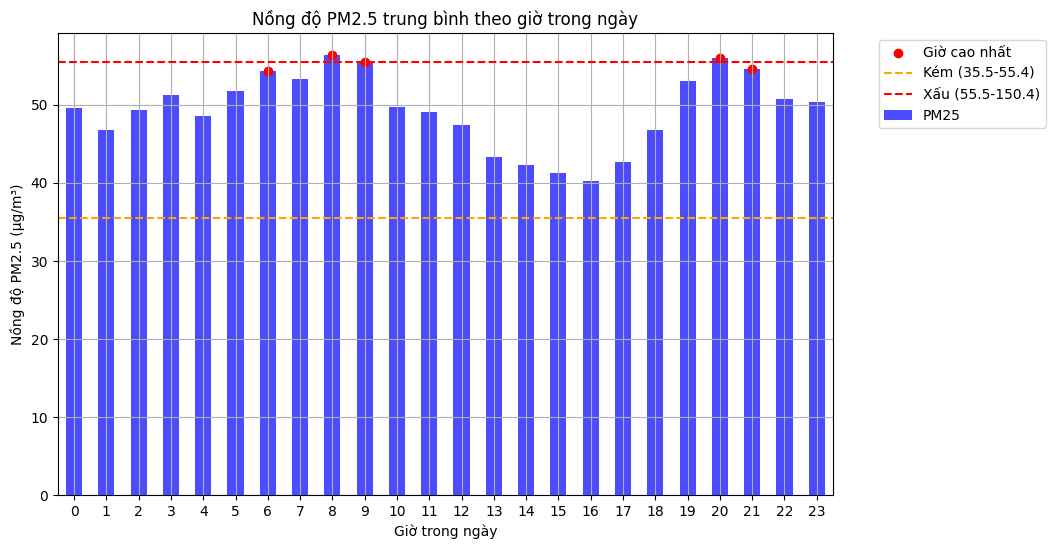

In [16]:


df['Local Time'] = pd.to_datetime(df['Local Time'], errors='coerce')


plt.figure(figsize=(10, 6))
hourly_pm25.plot(kind='bar', color='blue', alpha=0.7)  
plt.scatter(highest_hours.index, highest_hours.values, color='red', label='Giờ cao nhất') 
plt.title('Nồng độ PM2.5 trung bình theo giờ trong ngày')
plt.xlabel('Giờ trong ngày')
plt.ylabel('Nồng độ PM2.5 (μg/m³)')
plt.axhline(y=35.5, color='orange', linestyle='--', label='Kém (35.5-55.4)')
plt.axhline(y=55.5, color='red', linestyle='--', label='Xấu (55.5-150.4)')


plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)
plt.xticks(rotation='horizontal')

plt.show()


**-> KẾT LUẬN:**
Từ biểu đồ trên, có thể thấy nồng độ PM2.5 trung bình trong ngày tại Hà Nội dao động quanh mức 50–56 µg/m³, vượt ngưỡng “Kém” (35.5 µg/m³) và tiệm cận ngưỡng “Xấu” (55.5 µg/m³).

Cụ thể, các giờ có nồng độ cao nhất tập trung vào buổi sáng (6–9h) và buổi tối (19–21h) — trùng với hai khung giờ cao điểm giao thông, đồng thời điều kiện khuếch tán khí kém do hiện tượng [nghịch nhiệt](https://aqualife.vn/hien-tuong-nghich-nhiet-va-nhung-tac-hai-den-moi-truong-va-suc-khoe/) và tốc độ gió thấp.

Điều này cho thấy, hoạt động giao thông đô thị kết hợp với điều kiện khí tượng bất lợi về đêm là nguyên nhân chính khiến PM2.5 tăng cao, gây ra tình trạng ô nhiễm không khí nghiêm trọng trong các khoảng thời gian này.

### 3.3.3 Nồng độ PM2.5 trung bình mỗi mùa

In [17]:


df.set_index('Local Time', inplace=True)

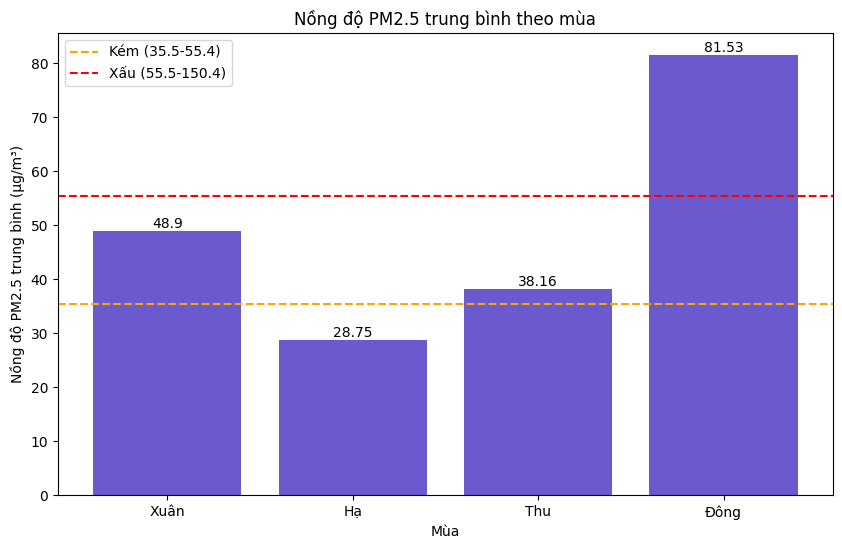

In [18]:
seasons = {
    'Xuân': [2, 3, 4],
    'Hạ': [5, 6, 7],
    'Thu': [8, 9, 10],
    'Đông': [11, 12, 1]
}


seasonal_pm25 = {}
for season, months in seasons.items():
    seasonal_pm25[season] = df.loc[df.index.month.isin(months), 'PM25'].mean()

plt.figure(figsize=(10, 6))
bars = plt.bar(seasonal_pm25.keys(), seasonal_pm25.values(), color='slateblue')
plt.title('Nồng độ PM2.5 trung bình theo mùa')
plt.xlabel('Mùa')
plt.ylabel('Nồng độ PM2.5 trung bình (μg/m³)')
plt.axhline(y=35.5, color='orange', linestyle='--', label='Kém (35.5-55.4)')
plt.axhline(y=55.5, color='red', linestyle='--', label='Xấu (55.5-150.4)')
plt.legend()


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2),
             ha='center', va='bottom')

plt.show()

**-> KẾT LUẬN:**
+ Mùa Đông ghi nhận mức cao nhất (≈ 81.53 µg/m³) — vượt xa ngưỡng “Xấu” (55.5 µg/m³).
→ Điều này do thời tiết lạnh, ít gió, độ ẩm cao và hiện tượng nghịch nhiệt làm bụi mịn tích tụ gần mặt đất.
+ Mùa Xuân cũng có mức PM2.5 tương đối cao (≈ 48.9 µg/m³), nằm trong vùng “Kém”.
+ Mùa Thu ở mức trung bình (≈ 38.16 µg/m³), thấp hơn so với mùa Xuân nhưng vẫn vượt ngưỡng an toàn.
+ Mùa Hè là mùa có chất lượng không khí tốt nhất, với PM2.5 trung bình chỉ ≈ 28.75 µg/m³, nhờ mưa nhiều, gió mạnh và đối lưu không khí tốt.


Nồng độ PM2.5 ở Hà Nội cao nhất vào mùa Đông – Xuân và thấp nhất vào mùa Hè, cho thấy điều kiện khí tượng và thời tiết có ảnh hưởng rõ rệt đến mức độ ô nhiễm không khí của thành phố.

## 3.4 Mưa
### 3.4.1 Chuỗi thời gian lượng mưa theo giờ

In [19]:

winter_months = [11, 12, 1]
spring_months = [2, 3, 4]
summer_months = [5, 6, 7]
autumn_months = [8, 9, 10]

years = [2023, 2024]

seasons = {
    'Xuân': [2, 3, 4],
    'Hạ': [5, 6, 7],
    'Thu': [8, 9, 10],
    'Đông': [11, 12, 1]
}


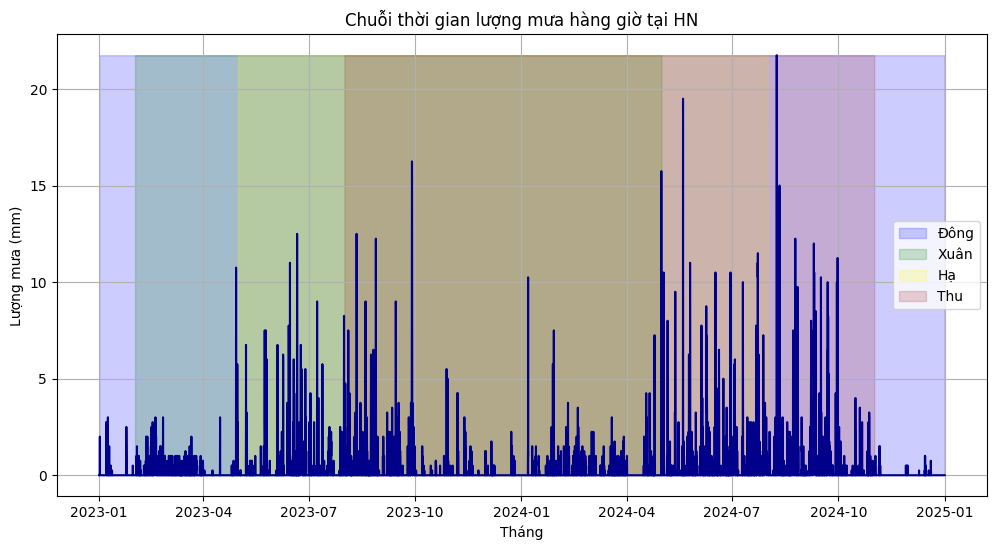

Lượng mưa hàng năm:  5049.5 mm


In [20]:

plt.figure(figsize=(12, 6))



plt.plot(df.index, df['Precipitation'], color='darkblue')


plt.fill_between(df.index[df.index.month.isin(winter_months)], df['Precipitation'].min(), df['Precipitation'].max(), color='blue', alpha=0.2, label='Đông')
plt.fill_between(df.index[df.index.month.isin(spring_months)], df['Precipitation'].min(), df['Precipitation'].max(), color='green', alpha=0.2, label='Xuân')
plt.fill_between(df.index[df.index.month.isin(summer_months)], df['Precipitation'].min(), df['Precipitation'].max(), color='yellow', alpha=0.2, label='Hạ')
plt.fill_between(df.index[df.index.month.isin(autumn_months)], df['Precipitation'].min(), df['Precipitation'].max(), color='brown', alpha=0.2, label='Thu')

plt.title('Chuỗi thời gian lượng mưa hàng giờ tại HN')
plt.xlabel('Tháng')
plt.ylabel('Lượng mưa (mm)')

plt.legend()
plt.grid(True)
plt.show()

annual_total_precipitation = df['Precipitation'].sum()

print("Lượng mưa hàng năm: ", annual_total_precipitation, "mm")

### 3.4.2 Tổng lượng mưa theo mùa 

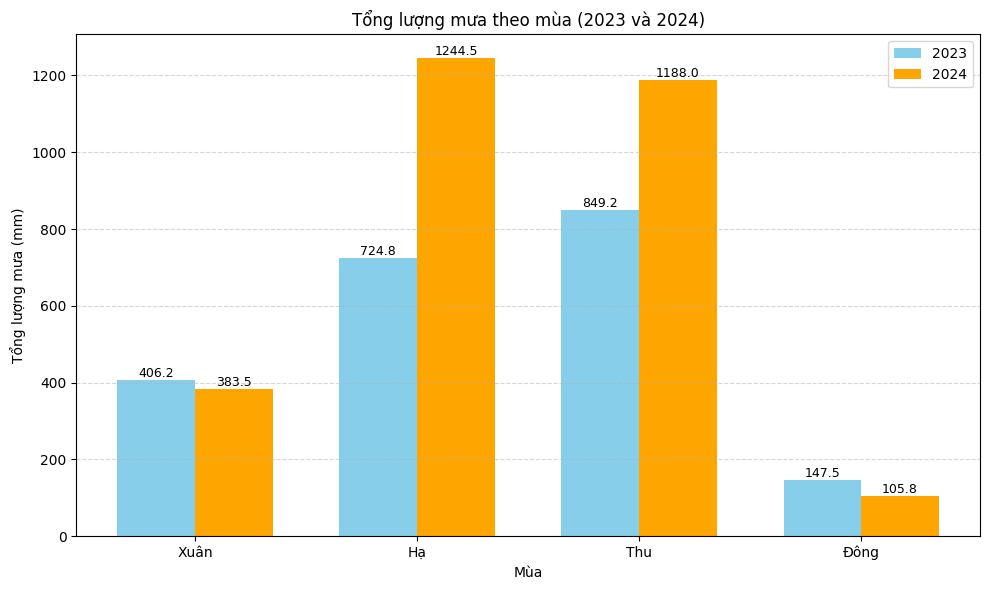

In [21]:

seasonal_precipitation_by_year = {
    year: {
        season: df.loc[(df.index.year == year) & (df.index.month.isin(months)), 'Precipitation'].sum()
        for season, months in seasons.items()
    }
    for year in years
}

seasons_list = list(seasons.keys())
values_2023 = [seasonal_precipitation_by_year[2023][s] for s in seasons_list]
values_2024 = [seasonal_precipitation_by_year[2024][s] for s in seasons_list]

x = range(len(seasons_list))
bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - bar_width/2 for i in x], values_2023, width=bar_width, color='skyblue', label='2023')
plt.bar([i + bar_width/2 for i in x], values_2024, width=bar_width, color='orange', label='2024')

plt.xticks(x, seasons_list)
plt.title('Tổng lượng mưa theo mùa (2023 và 2024)')
plt.xlabel('Mùa')
plt.ylabel('Tổng lượng mưa (mm)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, val in enumerate(values_2023):
    plt.text(i - bar_width/2, val, round(val, 1), ha='center', va='bottom', fontsize=9)
for i, val in enumerate(values_2024):
    plt.text(i + bar_width/2, val, round(val, 1), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


**-> KẾT LUẬN:** Khi xem xét biểu đồ và dữ liệu lượng mưa theo mùa, rõ ràng là mùa hè và mùa thu có lượng mưa lớn nhất, trong đó mùa thu là mùa mưa nhiều nhất. Ngược lại, mùa xuân thường xuyên có mưa phùn, trong khi mùa đông được ghi nhận là mùa khô nhất.

## 3.5 Áp suất
### 3.5.1 Chuỗi thời gian lượng áp suất theo giờ

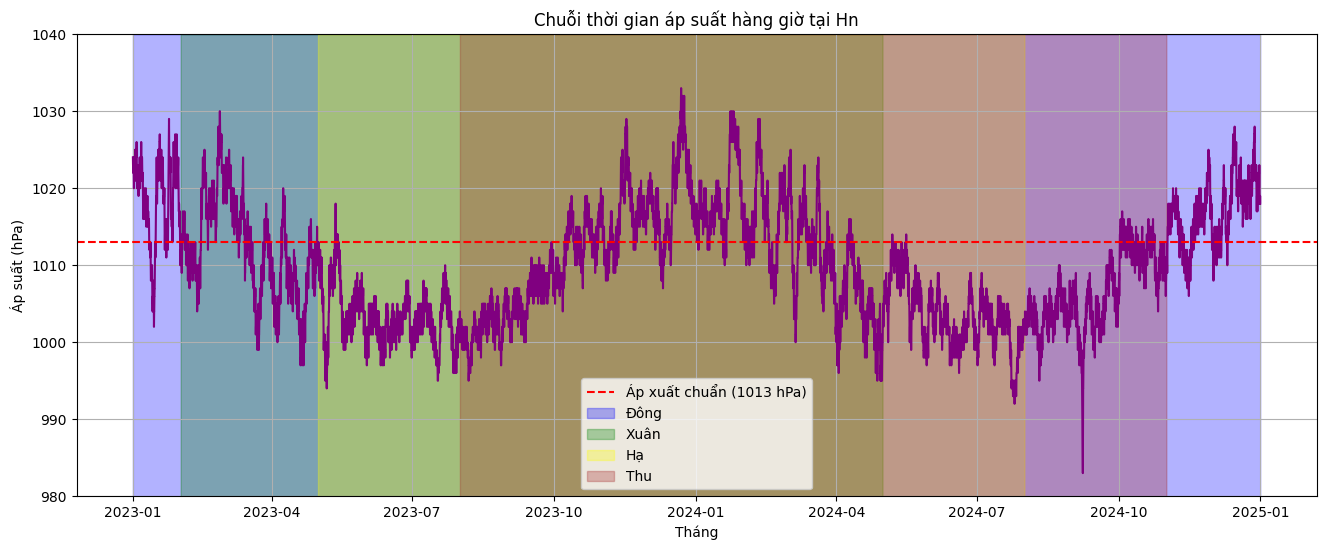

In [22]:


plt.figure(figsize=(16, 6))  
plt.plot(df.index, df['Pressure'], color='purple')  

plt.axhline(y=1013, color='red', linestyle='--', label='Áp xuất chuẩn (1013 hPa)')


plt.fill_between(df.index[df.index.month.isin(winter_months)], 980, 1040, color='blue', alpha=0.3, label='Đông')
plt.fill_between(df.index[df.index.month.isin(spring_months)], 980, 1040, color='green', alpha=0.3, label='Xuân')
plt.fill_between(df.index[df.index.month.isin(summer_months)], 980, 1040, color='yellow', alpha=0.3, label='Hạ')
plt.fill_between(df.index[df.index.month.isin(autumn_months)], 980, 1040, color='brown', alpha=0.3, label='Thu')

plt.title('Chuỗi thời gian áp suất hàng giờ tại Hn') 
plt.xlabel('Tháng')  
plt.ylabel('Áp suất (hPa)')  
plt.ylim(980, 1040) 
plt.grid(True)  
plt.legend() 
plt.show()  

**-> KẾT LUẬN:** 
- Mùa Đông: áp suất cao hơn mức chuẩn, dao động quanh 1020–1030 hPa → thời tiết lạnh, khô, ổn định → đặc trưng mùa Đông miền Bắc.
- Mùa Xuân : áp suất giảm nhẹ, nhiều biến động → thời tiết ẩm, mưa phùn, gió mùa.
- Mùa Hạ: áp suất thấp nhất năm (~995–1005 hPa) → thời kỳ nóng ẩm, mưa nhiều, dông bão.
- Mùa Thu: áp suất tăng trở lại, thời tiết mát, khô, ít mưa.

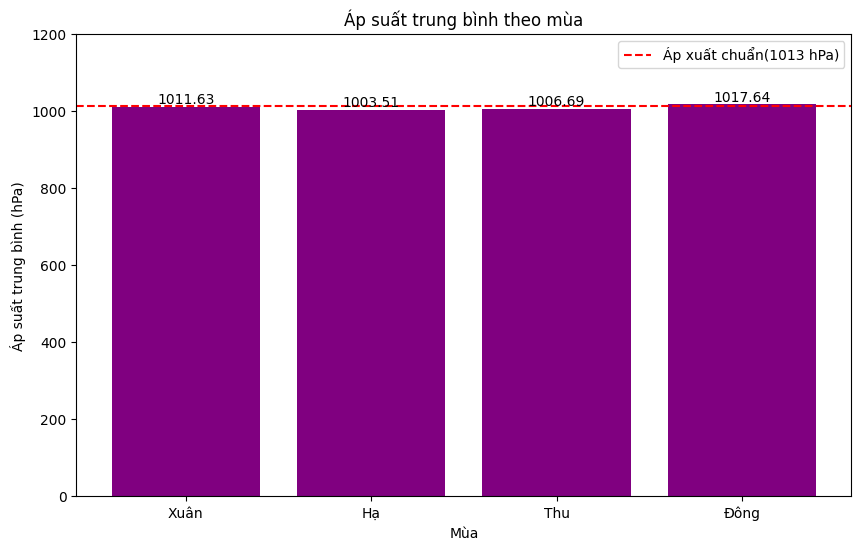

In [23]:
seasonal_humid = {}
for season, months in seasons.items():
    seasonal_humid[season] = df.loc[df.index.month.isin(months), 'Pressure'].mean()


plt.figure(figsize=(10, 6))
bars = plt.bar(seasonal_humid.keys(), seasonal_humid.values(), color='purple')
plt.axhline(y=1013, color='red', linestyle='--', label='Áp xuất chuẩn(1013 hPa)')
plt.title('Áp suất trung bình theo mùa')
plt.xlabel('Mùa')
plt.ylabel('Áp suất trung bình (hPa)')
plt.ylim(0, 1200)  

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2),
             ha='center', va='bottom')
plt.legend()
plt.show()


Trong các biểu đồ được mô tả ở trên, mức áp suất tại Hà Nội trong mùa hè và mùa thu giảm đáng kể xuống dưới mức chuẩn. Theo [National Geographic](https://education.nationalgeographic.org/resource/atmospheric-pressure/), những sai lệch như vậy thường đi kèm với các hệ thống áp thấp, thường báo hiệu mây mù, gió mạnh và lượng mưa. Hiện tượng này cho thấy lượng mưa lớn được quan sát thấy trong các mùa này. Ngược lại, mùa đông có mức áp suất khí quyển cao nhất, dẫn đến không khí tù đọng. Theo giải thích của [University Corporation for Atmospheric Research](https://scied.ucar.edu/learning-zone/air-quality/how-weather-affects-air-quality), không khí tù đọng này có thể giữ lại các chất ô nhiễm từ khí thải xe cộ và nhà máy trong khí quyển thành phố, dẫn đến nồng độ PM2.5 tăng cao trong mùa. Trong khi đó, các số liệu áp suất vào mùa xuân dao động quanh mức chuẩn, cho thấy điều kiện khí quyển tương đối ổn định trong thời gian đó.

## 3.6 Độ ẩm
### 3.6.1 Chuỗi thời gian độ ẩm theo giờ

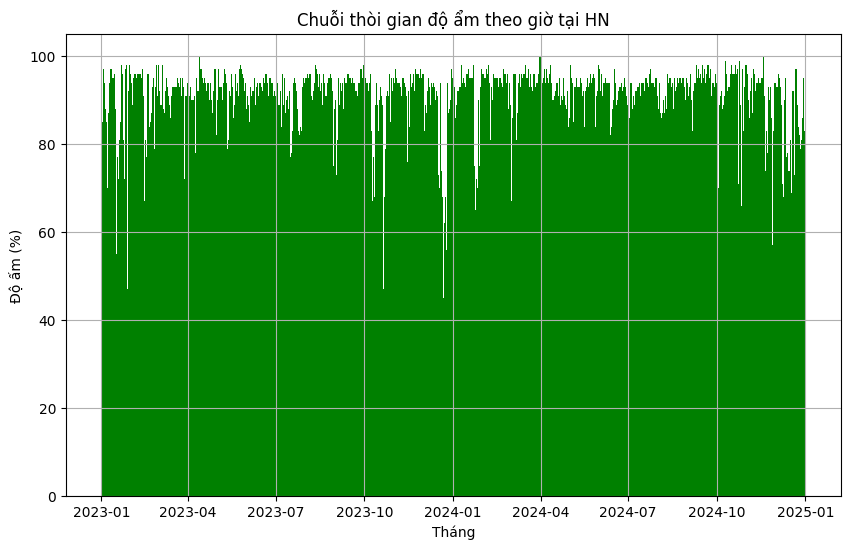

Độ ẩm trung bình hàng năm 77.97 %


In [24]:

plt.figure(figsize=(10, 6))  
plt.bar(df.index, df['Relative Humidity'], color='green', linestyle='-')  
plt.title('Chuỗi thòi gian độ ẩm theo giờ tại HN')  
plt.xlabel('Tháng')  
plt.ylabel('Độ ấm (%)')  
plt.grid(True) 
plt.show()  


average_annual_rh = df["Relative Humidity"].mean()

print("Độ ẩm trung bình hàng năm", round(average_annual_rh, 2), '%')

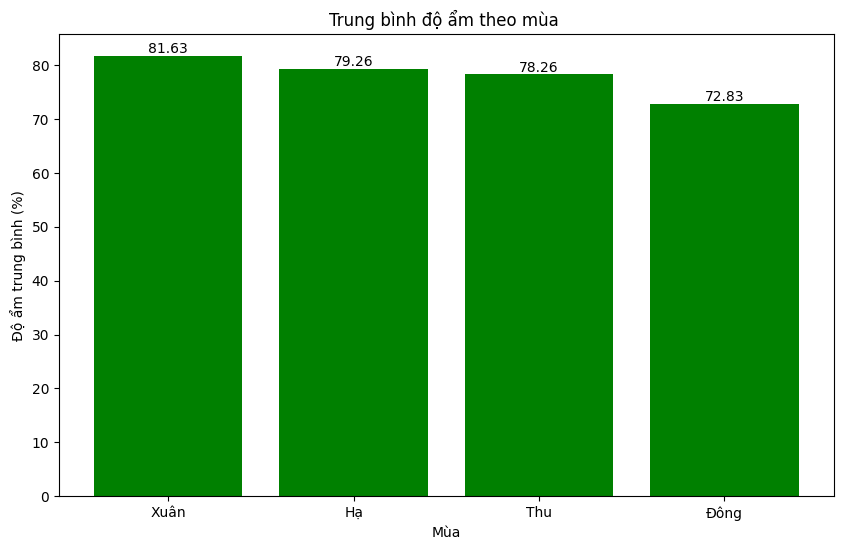

In [25]:
seasonal_humid = {}
for season, months in seasons.items():
    seasonal_humid[season] = df.loc[df.index.month.isin(months), 'Relative Humidity'].mean()


plt.figure(figsize=(10, 6))
bars = plt.bar(seasonal_humid.keys(), seasonal_humid.values(), color='green')
plt.title('Trung bình độ ẩm theo mùa ')
plt.xlabel('Mùa')
plt.ylabel('Độ ẩm trung bình (%)')


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2),
             ha='center', va='bottom')

plt.show()

Độ ẩm trung bình năm đạt khoảng 77.97%, là mức cao ổn định, cho thấy Hà Nội có môi trường ẩm quanh năm.
Các giai đoạn dao động mạnh thường trùng với các thời điểm chuyển mùa (đặc biệt từ Xuân → Hạ và Thu → Đông), khi nhiệt độ và lượng mưa thay đổi nhanh chóng.
Hà Nội có độ ẩm cao quanh năm, ít khi dưới 70%, điều này lý giải tại sao mùa hè nóng thường đi kèm cảm giác oi bức, còn mùa đông lại khô và hanh.

Độ ẩm cao nhất vào mùa Xuân → dễ gây ra mưa phùn, ẩm mốc, ảnh hưởng đến sức khỏe và sinh hoạt.

Độ ẩm thấp nhất vào mùa Đông → tạo nên không khí lạnh khô, làm da khô, nứt nẻ, bụi mịn dễ phát tán.

## 3.7 Nhiệt độ


c:\Users\hungd\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


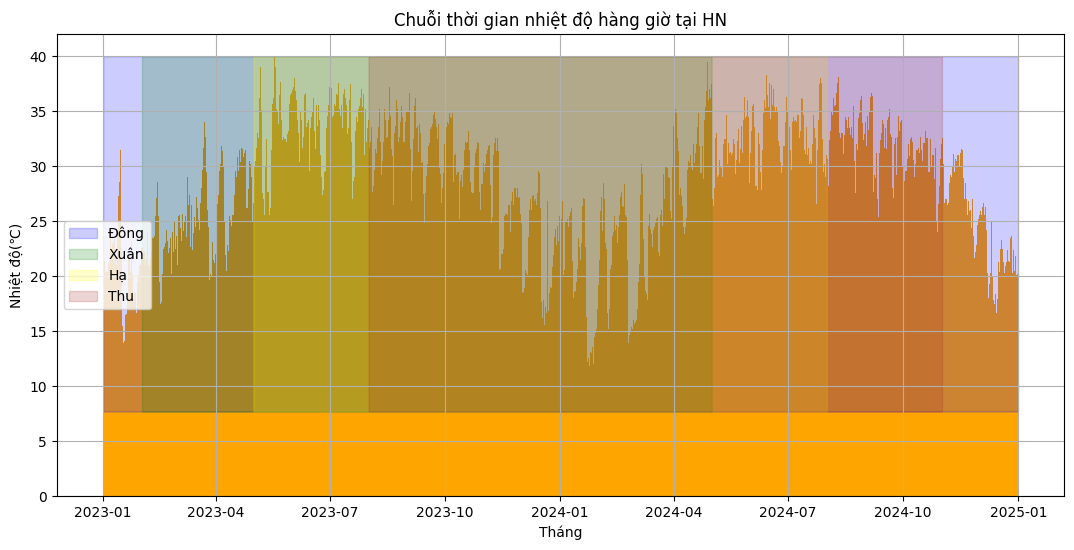

Nhiệt độ trung bình : 25.37 ℃ 



In [26]:

plt.figure(figsize=(13, 6))


plt.bar(df.index, df['Temperature'], color='orange', linestyle='-')


plt.fill_between(df.index[df.index.month.isin(winter_months)], df['Temperature'].min(), df['Temperature'].max(), color='blue', alpha=0.2, label='Đông')
plt.fill_between(df.index[df.index.month.isin(spring_months)], df['Temperature'].min(), df['Temperature'].max(), color='green', alpha=0.2, label='Xuân')
plt.fill_between(df.index[df.index.month.isin(summer_months)], df['Temperature'].min(), df['Temperature'].max(), color='yellow', alpha=0.2, label='Hạ')
plt.fill_between(df.index[df.index.month.isin(autumn_months)], df['Temperature'].min(), df['Temperature'].max(), color='brown', alpha=0.2, label='Thu')


plt.title('Chuỗi thời gian nhiệt độ hàng giờ tại HN')
plt.xlabel('Tháng')
plt.ylabel('Nhiệt độ(℃)')


plt.legend()

plt.grid(True)
plt.show()

average_annual_temperature = df['Temperature'].mean()
print("Nhiệt độ trung bình :", round(average_annual_temperature, 2), "℃ \n")

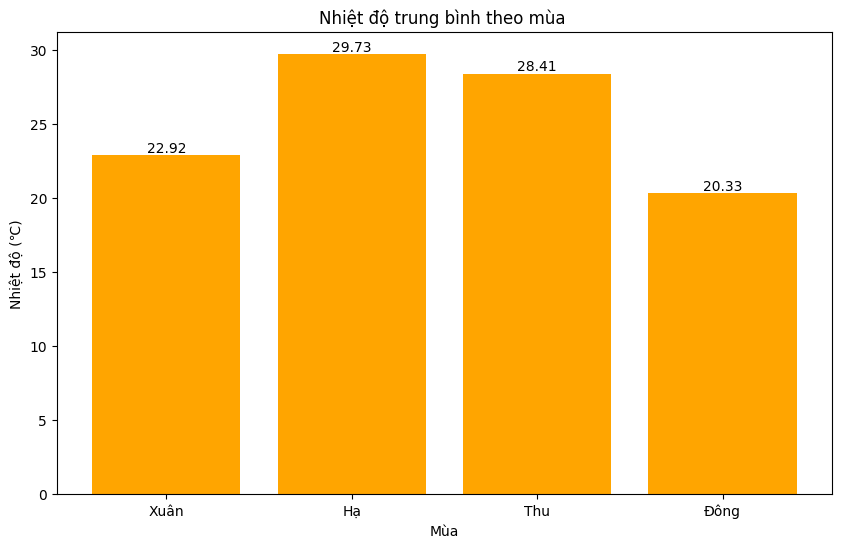

In [27]:
seasonal_temp = {}
for season, months in seasons.items():
    seasonal_temp[season] = df.loc[df.index.month.isin(months), 'Temperature'].mean()


plt.figure(figsize=(10, 6))
bars = plt.bar(seasonal_temp.keys(), seasonal_temp.values(), color='orange')
plt.title('Nhiệt độ trung bình theo mùa ')
plt.xlabel('Mùa')
plt.ylabel('Nhiệt độ (℃)')


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2),
             ha='center', va='bottom')

plt.show()

## 3.8 Tốc độ gió


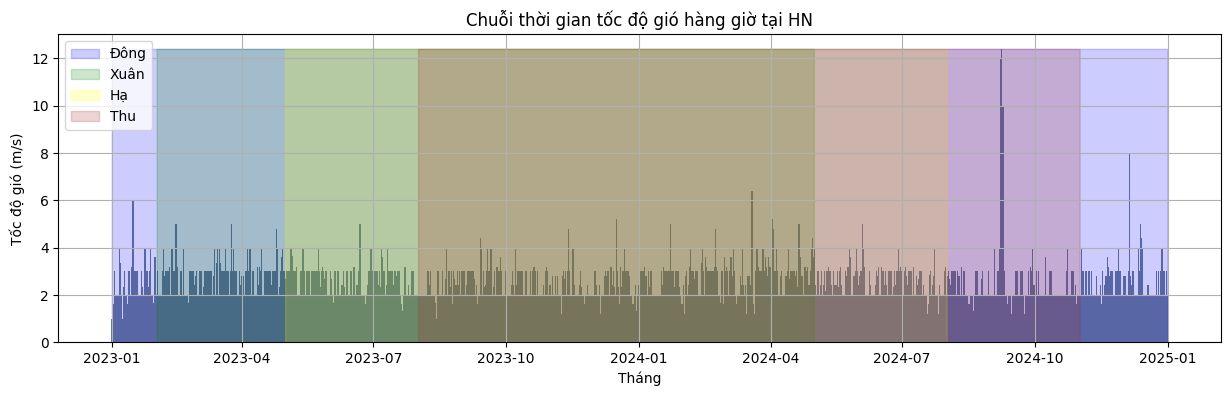

Tốc độ gió trung bình: 1.62 m/s



In [28]:
plt.figure(figsize=(15, 4))

plt.bar(df.index, df['Wind Speed'], color='slategray', linestyle='-')


plt.fill_between(df.index[df.index.month.isin(winter_months)], df['Wind Speed'].min(), df['Wind Speed'].max(), color='blue', alpha=0.2, label='Đông')
plt.fill_between(df.index[df.index.month.isin(spring_months)], df['Wind Speed'].min(), df['Wind Speed'].max(), color='green', alpha=0.2, label='Xuân')
plt.fill_between(df.index[df.index.month.isin(summer_months)], df['Wind Speed'].min(), df['Wind Speed'].max(), color='yellow', alpha=0.2, label='Hạ')
plt.fill_between(df.index[df.index.month.isin(autumn_months)], df['Wind Speed'].min(), df['Wind Speed'].max(), color='brown', alpha=0.2, label='Thu')


plt.title('Chuỗi thời gian tốc độ gió hàng giờ tại HN')
plt.xlabel('Tháng')
plt.ylabel('Tốc độ gió (m/s)')

plt.legend(loc='upper left')
plt.grid(True)
plt.show()


average_annual_wind_speed = df['Wind Speed'].mean()


print("Tốc độ gió trung bình:", round(average_annual_wind_speed, 2), "m/s\n")

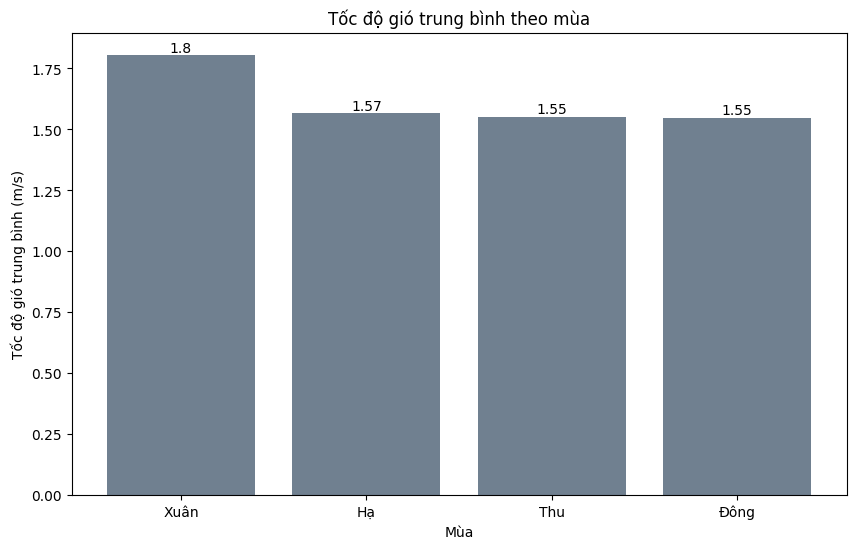

In [29]:
seasonal_wind_speed = {}
for season, months in seasons.items():
    seasonal_wind_speed[season] = df.loc[df.index.month.isin(months), 'Wind Speed'].mean()


plt.figure(figsize=(10, 6))
bars = plt.bar(seasonal_wind_speed.keys(), seasonal_wind_speed.values(), color='slategray')
plt.title('Tốc độ gió trung bình theo mùa')
plt.xlabel('Mùa')
plt.ylabel('Tốc độ gió trung bình (m/s)')


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2),
             ha='center', va='bottom')

plt.show()

Nhìn chung, Hà Nội có tốc độ gió tương đối thấp, với tốc độ gió trung bình hàng năm là 1,62 m/s. Trong 2 năm mùa xuân ghi nhận tốc độ gió trung bình cao nhất, có thể do ảnh hưởng của gió mùa Đông Bắc. Mùa hè tiếp theo có tốc độ gió trung bình cao thứ hai, có thể do mưa rào thường xuyên. Điều thú vị là mùa thu và mùa đông có tốc độ gió tương tự nhau.

# III. Ảnh hưởng của thời tiết đến chất lượng không khí 
Báo [Kinh tế và Dự báo](https://kinhtevadubao.vn/chi-so-chat-luong-khong-khi-la-gi-anh-huong-cua-o-nhiem-khong-khi-den-suc-khoe-con-nguoi-30928.html?utm_source=chatgpt.com) cho biết chỉ số AQI thường được tính toán dựa trên mức độ ô nhiễm của một số chất khí như PM2.5 (bụi mịn), PM10, ozone (O3), NO2 (nitrogen dioxide), SO2 (sulfur dioxide), và CO (carbon monoxide)

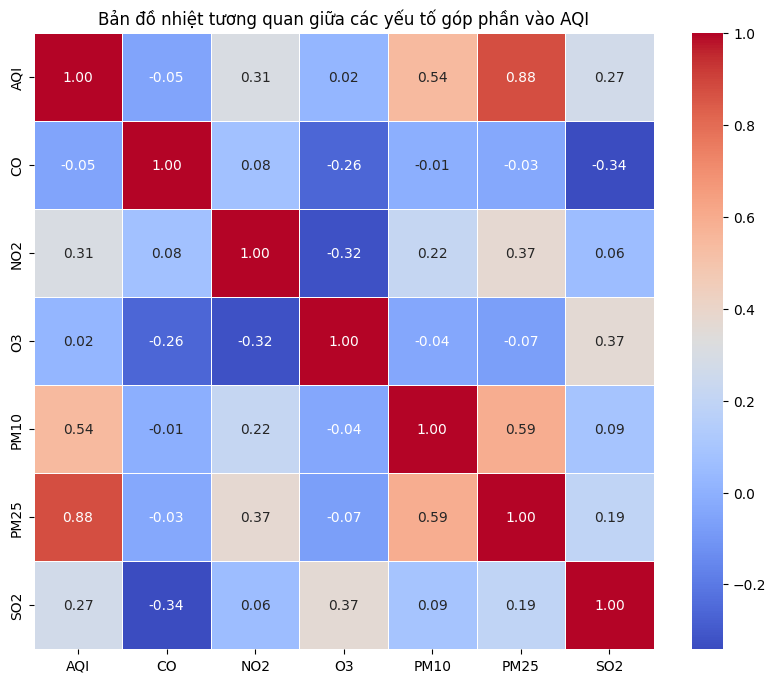

In [30]:
corr_columns = ['AQI', 'CO', 'NO2', 'O3', 'PM10', 'PM25', 'SO2']

correlation_matrix = df[corr_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Bản đồ nhiệt tương quan giữa các yếu tố góp phần vào AQI')
plt.show()

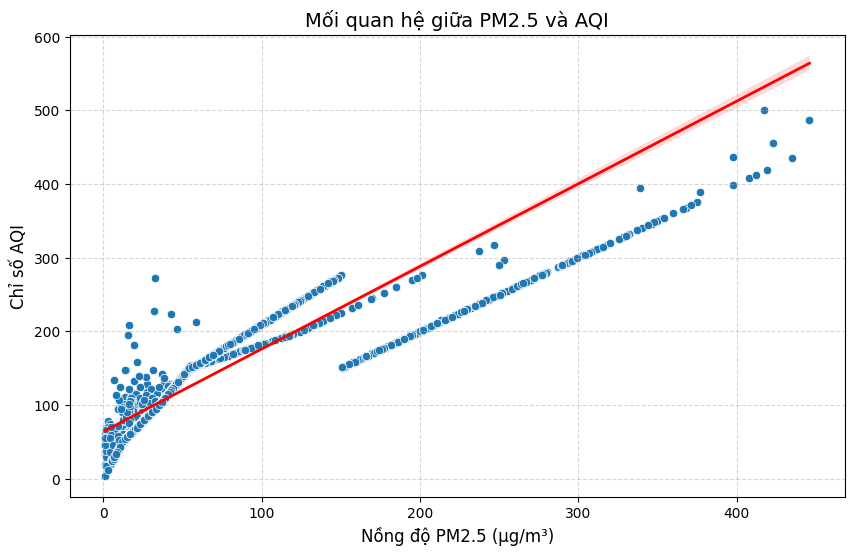

In [31]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='PM25', y='AQI')
sns.regplot(data=df, x='PM25', y='AQI', scatter=False, color='red', line_kws={'linewidth': 2} )

plt.title('Mối quan hệ giữa PM2.5 và AQI', fontsize=14)
plt.xlabel('Nồng độ PM2.5 (μg/m³)', fontsize=12)
plt.ylabel('Chỉ số AQI', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

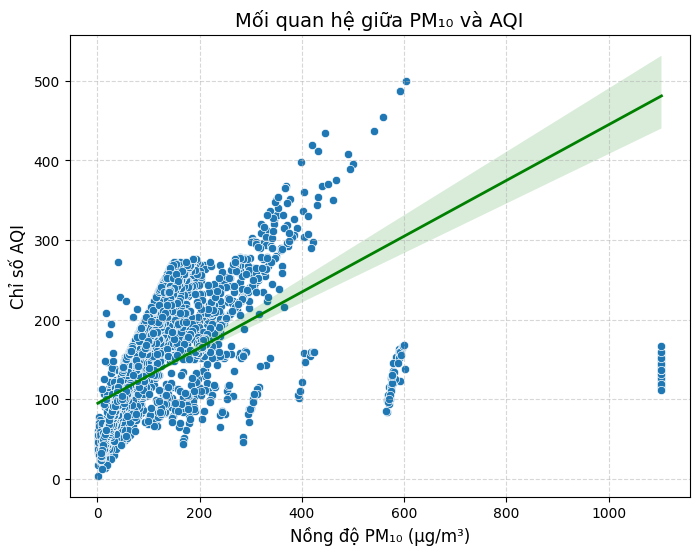

In [32]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PM10', y='AQI')
sns.regplot(data=df, x='PM10', y='AQI', scatter=False, color='green', line_kws={"linewidth": 2})

plt.title('Mối quan hệ giữa PM₁₀ và AQI', fontsize=14)
plt.xlabel('Nồng độ PM₁₀ (µg/m³)', fontsize=12)
plt.ylabel('Chỉ số AQI', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**-> KẾT LUẬN:**
- Phân tích ma trận tương quan cho thấy PM2.5 là yếu tố quyết định chính đối với chỉ số AQI tại Hà Nội, có hệ số tương quan 0.88 — mức cực cao.
- Ngoài ra, PM10 và NO2 cũng góp phần làm tăng mức độ ô nhiễm, nhưng yếu hơn đáng kể.
- Các khí khác như CO, SO2, O3 có ảnh hưởng rất nhỏ
- Theo [VnExpress](https://vnexpress.net/chat-luong-khong-khi-ha-noi-suy-giam-dien-rong-4718820.html), cũng nhắc đến PM2.5 (chiếm 66.3%) là nguyên nhân chính dẫn đến chất lượng ko khí bị suy giảm 
-> PM2.5 đc chọn lm biến số đo lường chất lượng ko khí 

## 3.1 Mưa

### 3.1.1 Giờ mưa

In [33]:
accumulated_hours_of_rain = 0
accumulated_hours_list = []

for precipitation in df['Precipitation']:
    if precipitation > 0:
        accumulated_hours_of_rain += 1
    else:
        accumulated_hours_of_rain = 0
        
    accumulated_hours_list.append(accumulated_hours_of_rain)
    
df['Accumulated Hours of Rain'] = accumulated_hours_list
df.head(3)
    

,UTC Time,City,Country Code,Timezone,AQI,CO,NO2,O3,PM10,PM25,...,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed,month,year,HolidayName,IsHoliday,Accumulated Hours of Rain
Local Time,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,2022-12-31T17:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,155,224.5,9.0,55.7,73.8,59.0,...,1024,73,14.8,0.0,0.66,1,2023,Ngày thường,False,0
2023-01-01 01:00:00,2022-12-31T18:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,171,206.0,6.0,56.0,88.8,71.0,...,1023,75,14.6,0.0,1.00,1,2023,Ngày thường,False,0
2023-01-01 02:00:00,2022-12-31T19:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,179,203.7,6.0,54.0,96.3,77.0,...,1023,79,14.3,0.0,1.00,1,2023,Ngày thường,False,0


In [34]:
df['Accumulated Hours of Rain'].describe()

count    17544.000000
mean         1.249145
std          4.114975
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         51.000000
Name: Accumulated Hours of Rain, dtype: float64

### 3.1.2 Mối quan hệ giữa giờ mưa và nồng độ PM2.5

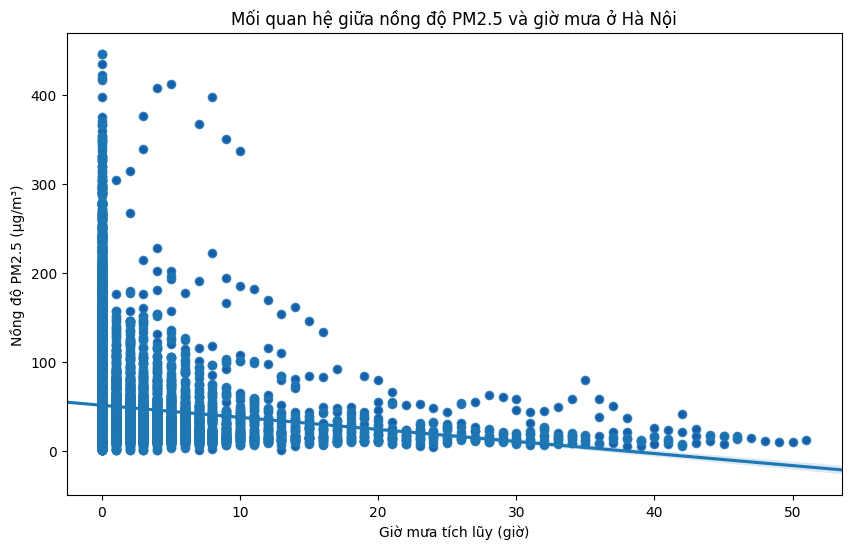

Hệ số tương quan: -0.13


In [35]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Accumulated Hours of Rain', y='PM25', color='darkblue')

sns.regplot(data=df, x='Accumulated Hours of Rain', y='PM25', truncate=False)
correlation_coefficient = df['Accumulated Hours of Rain'].corr(df['PM25'])


plt.title('Mối quan hệ giữa nồng độ PM2.5 và giờ mưa ở Hà Nội')
plt.xlabel('Giờ mưa tích lũy (giờ)')
plt.ylabel('Nồng độ PM2.5 (μg/m³)')

plt.show()


print(f"Hệ số tương quan: {correlation_coefficient:.2f}")

### 3.1.3 Mối quan hệ giữa lượng mưa và nồng độ PM2.5

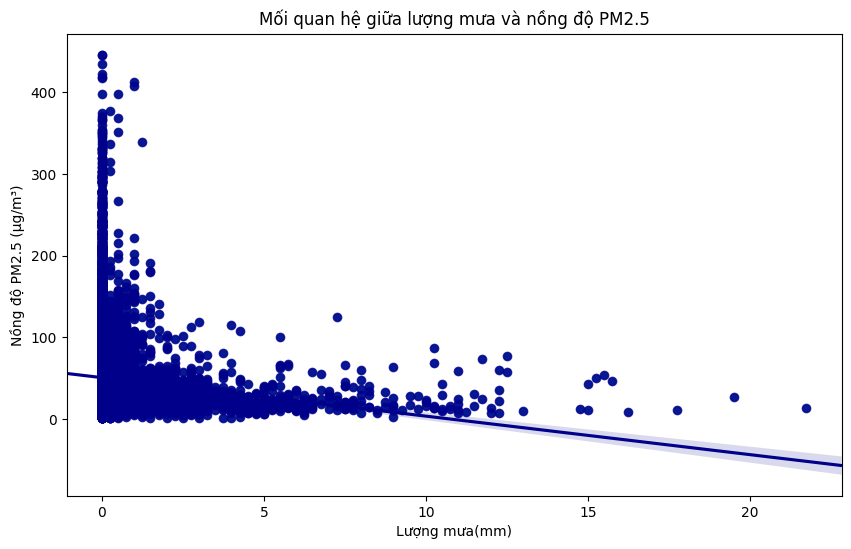

Hệ số tương quan: -0.11


In [36]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Precipitation', y='PM25')


sns.regplot(data=df, x='Precipitation', y='PM25', truncate= False, color='darkblue')

correlation_coefficient = df['Precipitation'].corr(df['PM25'])

plt.title('Mối quan hệ giữa lượng mưa và nồng độ PM2.5')
plt.xlabel('Lượng mưa(mm)')
plt.ylabel('Nồng độ PM2.5 (μg/m³)')

plt.show()

print(f"Hệ số tương quan: {correlation_coefficient:.2f}")

## 3.2 Ảnh hưởng của áp suất đến AQI

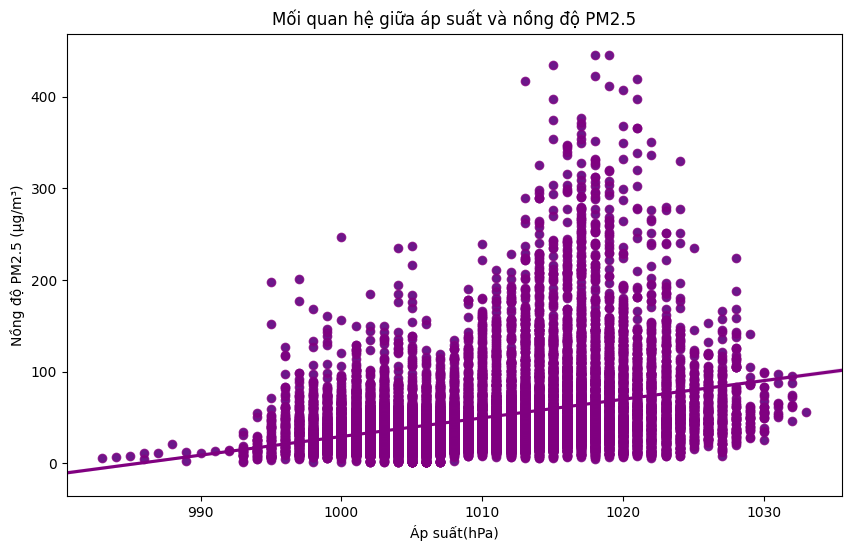

Hệ số tương quan: 0.36


In [37]:

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Pressure', y='PM25')
sns.regplot(data=df, x='Pressure', y='PM25', truncate= False, color='purple')


correlation_coefficient = df['Pressure'].corr(df['PM25'])


plt.title('Mối quan hệ giữa áp suất và nồng độ PM2.5')
plt.xlabel('Áp suất(hPa)')
plt.ylabel('Nồng độ PM2.5 (μg/m³)')

plt.show()

print(f"Hệ số tương quan: {correlation_coefficient:.2f}")

## 3.3 Ảnh hưởng của độ ẩm đến AQI

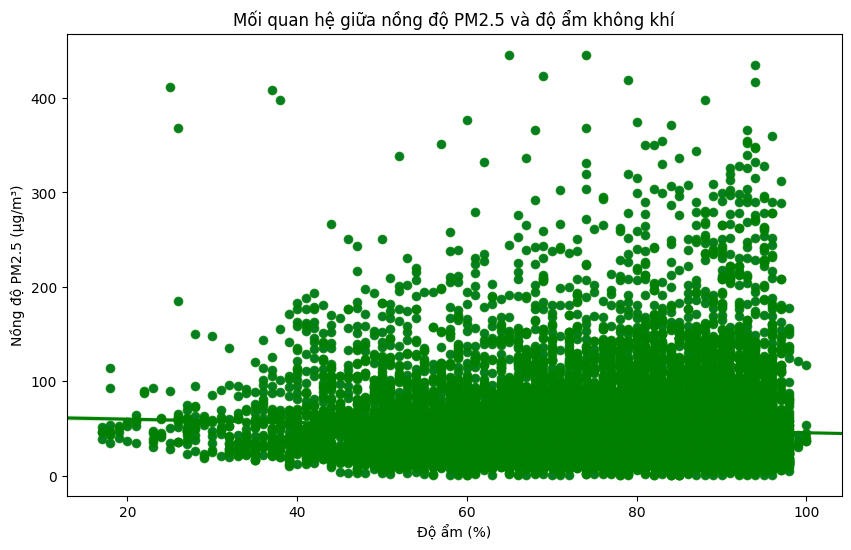

Hệ số tương quan: -0.06


In [38]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Relative Humidity', y='PM25')

sns.regplot(data=df, x='Relative Humidity', y='PM25', truncate=False, color='green')


correlation_coefficient = df['Relative Humidity'].corr(df['PM25'])

plt.title('Mối quan hệ giữa nồng độ PM2.5 và độ ẩm không khí')
plt.xlabel('Độ ẩm (%)')
plt.ylabel('Nồng độ PM2.5 (μg/m³)')

plt.show()


print(f"Hệ số tương quan: {correlation_coefficient:.2f}")

## 3.4 Ảnh hưởng của nhiệt độ đến AQI

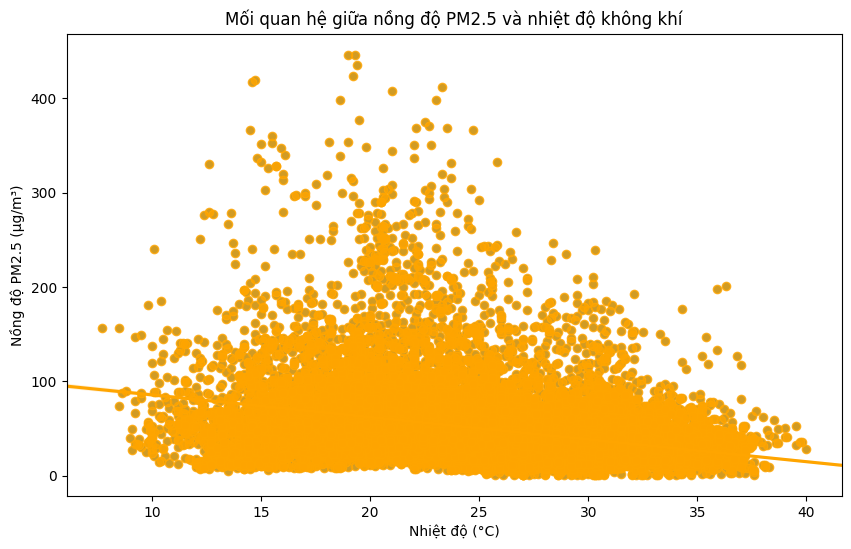

Hệ số tương quan: -0.31


In [39]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Temperature', y='PM25')
sns.regplot(data=df, x='Temperature', y='PM25', truncate=False, color='orange')

correlation_coefficient = df['Temperature'].corr(df['PM25'])
plt.title('Mối quan hệ giữa nồng độ PM2.5 và nhiệt độ không khí')
plt.xlabel('Nhiệt độ (°C)')
plt.ylabel('Nồng độ PM2.5 (μg/m³)')

plt.show()

print(f"Hệ số tương quan: {correlation_coefficient:.2f}")

## 3.5 Ảnh hưởng của tốc độ gió đến AQI

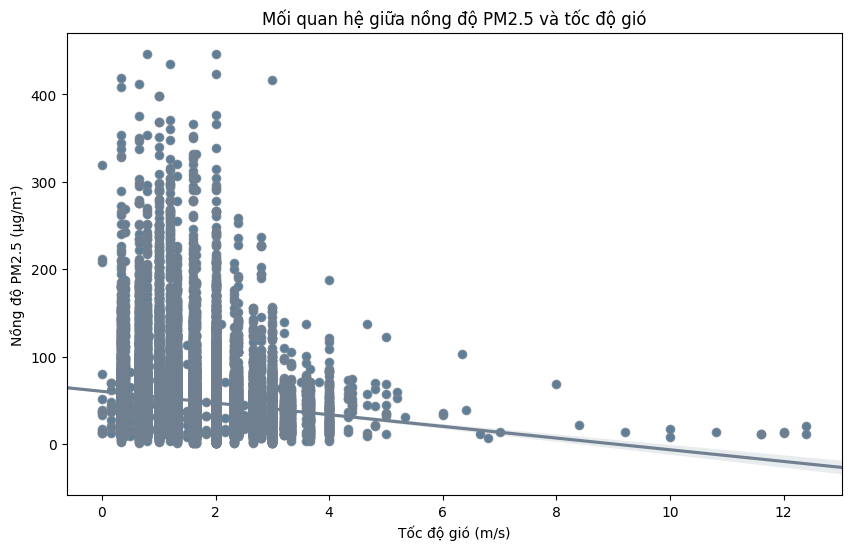

Hệ số tương quan: -0.13


In [40]:

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Wind Speed', y='PM25')
sns.regplot(data=df, x='Wind Speed', y='PM25', truncate=False, color='slategray')
correlation_coefficient = df['Wind Speed'].corr(df['PM25'])


plt.title('Mối quan hệ giữa nồng độ PM2.5 và tốc độ gió')
plt.xlabel('Tốc độ gió (m/s)')
plt.ylabel('Nồng độ PM2.5 (μg/m³)')

plt.show()


print(f"Hệ số tương quan: {correlation_coefficient:.2f}")